# Tiny Companion: PSI for Drift

This notebook builds PSI slowly using one numeric feature.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
%config InlineBackend.figure_format = 'retina'

## Step 1: Create training and production values

In [8]:
train = np.random.normal(30, 5, 500)
prod  = np.random.normal(38, 7, 500)

## Step 2: Put values into bins and compare percentages

In [9]:
bins = [15, 25, 32, 40, 50, 65]
train_pct, _ = np.histogram(train, bins=bins)
prod_pct, _ = np.histogram(prod, bins=bins)
train_pct = train_pct / train_pct.sum()
prod_pct = prod_pct / prod_pct.sum()
labels = ['15-25', '25-32', '32-40', '40-50', '50+']

pd.DataFrame({'train_pct': train_pct, 'prod_pct': prod_pct}, index=labels)

,train_pct,prod_pct
15-25,0.150301,0.024
25-32,0.517034,0.152
32-40,0.306613,0.440
40-50,0.026052,0.332
50+,0.000000,0.052


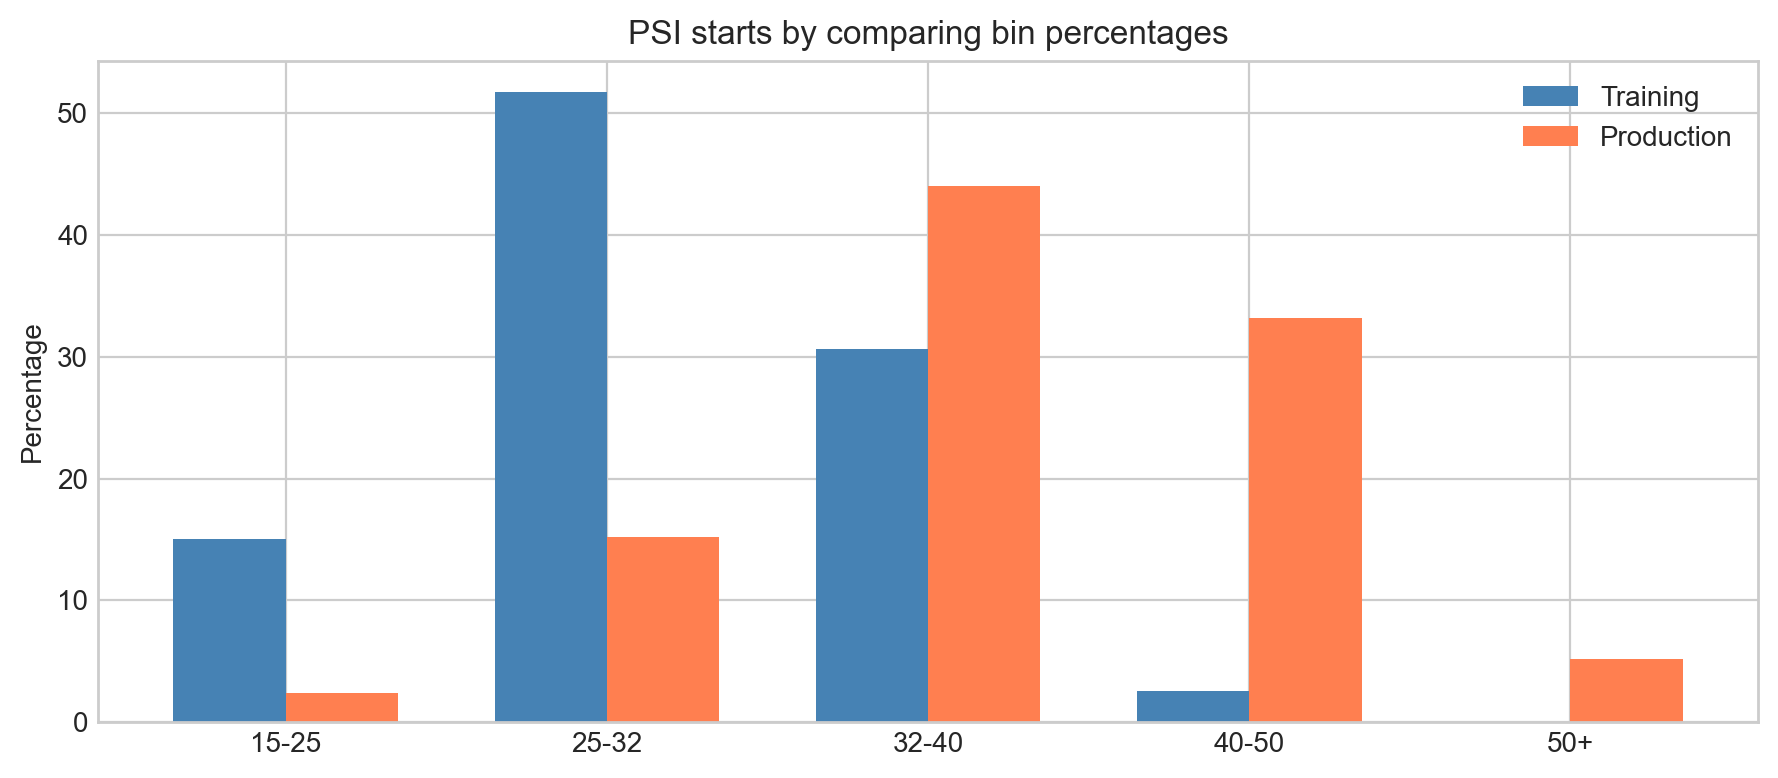

In [10]:
x = np.arange(len(labels))
w = 0.35
plt.figure(figsize=(9,4))
plt.bar(x - w/2, train_pct*100, w, label='Training', color='steelblue')
plt.bar(x + w/2, prod_pct*100, w, label='Production', color='coral')
plt.xticks(x, labels)
plt.ylabel('Percentage')
plt.title('PSI starts by comparing bin percentages')
plt.legend()
plt.tight_layout()
plt.show()

## Step 3: Compute PSI

You do not need to memorize the formula. The idea is:

- each bin contributes some mismatch
- bigger changes contribute more
- add those contributions to get PSI

In [5]:
eps = 1e-6
psi_per_bin = (prod_pct - train_pct) * np.log((prod_pct + eps) / (train_pct + eps))
psi_total = psi_per_bin.sum()

pd.DataFrame({'train_pct': train_pct, 'prod_pct': prod_pct, 'psi_contribution': psi_per_bin}, index=labels)

,train_pct,prod_pct,psi_contribution
15-25,0.150301,0.024,0.231705
25-32,0.517034,0.152,0.446883
32-40,0.306613,0.440,0.048178
40-50,0.026052,0.332,0.778638
50+,0.000000,0.052,0.564669


In [6]:
print(f'PSI = {psi_total:.3f}')
if psi_total < 0.10:
    print('Interpretation: little or no drift')
elif psi_total < 0.25:
    print('Interpretation: moderate drift')
else:
    print('Interpretation: significant drift')

PSI = 2.070
Interpretation: significant drift
